In [1]:
import json 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os 

data = json.load(open("data/sample.json", "r"))
concepts= list(data.keys())

model_names = [
    'meta-llama/Meta-Llama-3.1-8B-Instruct',
    'Qwen/Qwen2.5-7B-Instruct',
]

model_rename = {
    'meta-llama/Meta-Llama-3.1-8B-Instruct': 'Meta-Llama-3.1-8B-Instruct',
    'Qwen/Qwen2.5-7B-Instruct': 'Qwen2.5-7B-Instruct',
}

def get_num_layers(llm_name):
    if llm_name == "meta-llama/Meta-Llama-3.1-8B-Instruct":
        return 32
    elif llm_name == "Qwen/Qwen2.5-7B-Instruct":
        return 28
    else:
        raise ValueError(f"Unsupported model: {llm_name}")
    
results = {
    'model_name': [],
    'concept': [],
    'split': [],
    'init_seed': [],
    'layer_idx': [],
    'acc': [],
}
init_seeds = [42]
only_last_token = True

path = "outputs/raw_key_probers/{model_name}/{concept}/only_last_token_{only_last_token}/{init_seed}/layer_{layer_idx}_results.json"
for model_name in model_names:
    num_layers = get_num_layers(model_name)
    for concept_idx, concept in enumerate(concepts):
        for split in ["train", "test"]:
            for init_seed in init_seeds:
                for layer_idx in range(num_layers):
                    path_formatted = path.format(model_name=model_name, 
                                                concept=concept, 
                                                only_last_token=only_last_token, 
                                                init_seed=init_seed, 
                                                layer_idx=layer_idx)
                    if os.path.exists(path_formatted):
                        result = json.load(open(path_formatted, "r"))
                        for name in ['train', 'test']:
                            results['model_name'].append(model_rename[model_name])
                            results['concept'].append(concept_idx)
                            results['split'].append(name)
                            results['init_seed'].append(init_seed)
                            results['layer_idx'].append(layer_idx)
                            # results['acc'].append(max(result[f'{name}_accs']))
                            results['acc'].append(result[f'{name}_accs'][-1])
                    
dfs = pd.DataFrame(results)      
dfs    

,model_name,concept,split,init_seed,layer_idx,acc
0,Meta-Llama-3.1-8B-Instruct,0,train,42,0,0.833333
1,Meta-Llama-3.1-8B-Instruct,0,test,42,0,0.714286
2,Meta-Llama-3.1-8B-Instruct,0,train,42,1,0.833333
3,Meta-Llama-3.1-8B-Instruct,0,test,42,1,0.571429
4,Meta-Llama-3.1-8B-Instruct,0,train,42,2,1.000000
...,...,...,...,...,...,...
11995,Qwen2.5-7B-Instruct,49,test,42,25,1.000000
11996,Qwen2.5-7B-Instruct,49,train,42,26,1.000000
11997,Qwen2.5-7B-Instruct,49,test,42,26,1.000000
11998,Qwen2.5-7B-Instruct,49,train,42,27,1.000000


In [2]:
dfs.groupby(['model_name', 'split',]).count()
# print(dfs['concept'].unique())

concept  init_seed  layer_idx   acc
model_name                 split                                     
Meta-Llama-3.1-8B-Instruct test      3200       3200       3200  3200
                           train     3200       3200       3200  3200
Qwen2.5-7B-Instruct        test      2800       2800       2800  2800
                           train     2800       2800       2800  2800

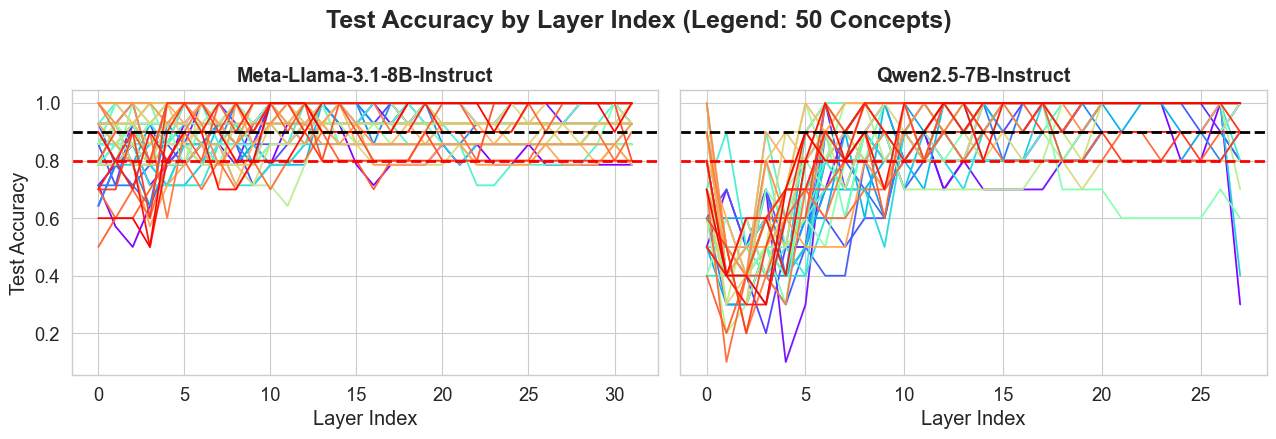

In [3]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.5)

fig, axes = plt.subplots(1, len(model_names), figsize=(13, 4.5), sharey=True)
axes = axes.flat
split='test'
for i, model_name in enumerate(model_names):
    ax = next(axes)
    temp = dfs[dfs['model_name'] == model_rename[model_name]]
    temp = temp[temp['split'] == split]
    sns.lineplot(data=temp, x='layer_idx', y='acc', ax=ax, 
                 hue='concept', legend=False,
                 palette='rainbow')
    ax.set_title(model_rename[model_name], fontweight='bold')
    ax.set_xlabel('Layer Index')
    ax.set_ylabel('Test Accuracy')
    ax.axhline(y=0.8, color='red', linestyle='--', lw=2)
    ax.axhline(y=0.9, color='#000000', linestyle='--', lw=2)
# fig.legend(title='Concept Index', bbox_to_anchor=(0.5, 1.2), loc='upper center', ncol=10)
fig.suptitle('Test Accuracy by Layer Index (Legend: 50 Concepts)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('test_accuracy_by_layer_index.png', bbox_inches='tight')
plt.show()

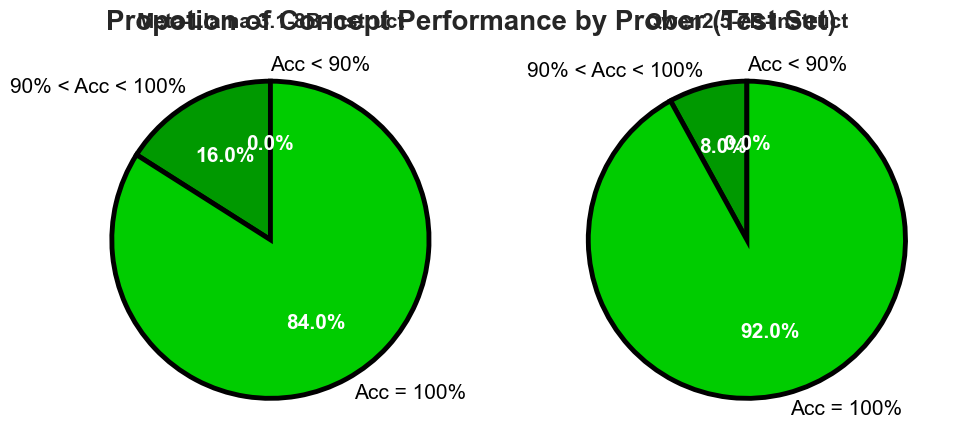

In [4]:
# chart 로 60% 70% 80% 90% 성능의 concept의 비율 (Pie Chart)
sns.set_theme(style="whitegrid")
# sns.set_palette("pastel")
sns.set_context("paper", font_scale=1.5)
split = 'test'  
df = dfs[dfs['split'] == split]

# 각 concept별 최고 성능 계산
concept_max_acc = df.groupby(['model_name', 'concept'])['acc'].max().reset_index()

# 성능 구간별로 분류
def categorize_acc(acc):
    if acc >= 1.0:
        return 'Acc = 100%'
    elif acc >= 0.9:
        return '90% < Acc < 100%'
    else:
        return 'Acc < 90%'
    
colors = ['#000000', 
          '#009900',
          '#00cc00']
categories_order = [
                    'Acc < 90%',
                    '90% < Acc < 100%',
                    'Acc = 100%',
                    ]
concept_max_acc['category'] = concept_max_acc['acc'].apply(categorize_acc)

# 각 모델별로 Pie Chart 생성
fig, axes = plt.subplots(1, len(model_names), figsize=(10, 5))
if len(model_names) == 1:
    axes = [axes]
else:
    axes = axes.flat


for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    model_data = concept_max_acc[concept_max_acc['model_name'] == model_rename[model_name]]
    
    # 각 카테고리별 비율 계산
    category_counts = model_data['category'].value_counts()
    category_counts = category_counts.reindex(categories_order, fill_value=0)
    
    # Pie Chart 생성
    wedges, texts, autotexts = ax.pie(
        category_counts.values,
        labels=category_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops=dict(color='black', fontsize=15),
        wedgeprops=dict(edgecolor='black', linewidth=3.5)
    )
    
    ax.set_title(f'{model_name.split("/")[-1]}', fontsize=15, pad=10, fontweight='bold')
    
    # 퍼센트 텍스트 스타일 조정
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

fig.suptitle('Propotion of Concept Performance by Prober (Test Set)', fontsize=20, fontweight='bold', y=0.9)
plt.tight_layout()
plt.savefig('pie_chart.png', bbox_inches='tight')
plt.show()


In [5]:
split = 'test'
maxes_means = [[], [], [], []]
for concept_idx, concept in enumerate(concepts):
    for m_idx, model_name in enumerate(model_names):
        temp = dfs[dfs['model_name'] == model_rename[model_name]]
        temp = temp[temp['split'] == split]
        temp = temp[temp['concept'] == concept_idx]
        max_acc = temp['acc'].max(skipna=True)
        maxes_means[m_idx].append(max_acc)
    
    for m_idx, model_name in enumerate(model_names):
        temp = dfs[dfs['model_name'] == model_rename[model_name]]
        temp = temp[temp['split'] == split]
        temp = temp[temp['concept'] == concept_idx]
        mean_acc = temp['acc'].mean(skipna=True)
        var_acc = temp['acc'].std(skipna=True)
        maxes_means[m_idx+2].append(mean_acc)

print("MAX / AVG", end =" | ")
print(f"{max(maxes_means[0]):.2f}", end =" | ")
print(f"{max(maxes_means[1]):.2f}", end =" | ")
print(f"{np.mean(maxes_means[2]):.2f}", end =" | ")
print(f"{np.mean(maxes_means[3]):.2f}", end =" | ")
print()
for concept_idx, concept in enumerate(concepts):
    print(f"{concept}", end =" | ")
    print(f"{maxes_means[0][concept_idx]:.2f}", end =" | ")
    print(f"{maxes_means[1][concept_idx]:.2f}", end =" | ")
    print(f"{maxes_means[2][concept_idx]:.2f}", end =" | ")
    print(f"{maxes_means[3][concept_idx]:.2f}", end =" | ")
    print()

MAX / AVG | 1.00 | 1.00 | 0.92 | 0.84 | 
나이 | 1.00 | 1.00 | 0.80 | 0.78 | 
성별 | 1.00 | 0.90 | 0.93 | 0.75 | 
학력 | 1.00 | 1.00 | 0.95 | 0.84 | 
직업 | 1.00 | 1.00 | 0.98 | 0.88 | 
결혼 여부 | 1.00 | 1.00 | 0.96 | 0.85 | 
출산 여부 | 0.93 | 1.00 | 0.89 | 0.82 | 
국적 | 0.93 | 1.00 | 0.85 | 0.80 | 
인종 | 1.00 | 0.90 | 0.99 | 0.75 | 
종교 | 1.00 | 1.00 | 0.91 | 0.83 | 
혼혈 여부 | 1.00 | 1.00 | 0.92 | 0.83 | 
어린이 | 1.00 | 1.00 | 0.91 | 0.86 | 
노인 | 1.00 | 1.00 | 0.94 | 0.79 | 
장애 여부 | 1.00 | 1.00 | 0.96 | 0.75 | 
외모(미모) | 1.00 | 1.00 | 0.93 | 0.88 | 
체형 | 0.93 | 1.00 | 0.89 | 0.82 | 
키 | 0.93 | 1.00 | 0.86 | 0.79 | 
정신건강 | 0.93 | 1.00 | 0.91 | 0.81 | 
경제적 지위 | 1.00 | 1.00 | 0.91 | 0.83 | 
가정환경 | 1.00 | 1.00 | 0.89 | 0.83 | 
성적지향 | 1.00 | 1.00 | 0.96 | 0.86 | 
출신학교(고교) | 1.00 | 0.90 | 0.91 | 0.80 | 
군필 여부 | 1.00 | 1.00 | 0.95 | 0.90 | 
직업군(예술가) | 1.00 | 1.00 | 0.92 | 0.81 | 
직업군(공무원) | 1.00 | 1.00 | 0.99 | 0.87 | 
이민자 여부 | 0.93 | 1.00 | 0.88 | 0.82 | 
사투리 사용 | 1.00 | 1.00 | 0.90 | 0.75 | 
섭식 습관(채식) | 1.00 | 1

In [6]:
dfs[dfs['model_name'] == 'Meta-Llama-3.1-8B-Instruct']

,model_name,concept,split,init_seed,layer_idx,acc
0,Meta-Llama-3.1-8B-Instruct,0,train,42,0,0.833333
1,Meta-Llama-3.1-8B-Instruct,0,test,42,0,0.714286
2,Meta-Llama-3.1-8B-Instruct,0,train,42,1,0.833333
3,Meta-Llama-3.1-8B-Instruct,0,test,42,1,0.571429
4,Meta-Llama-3.1-8B-Instruct,0,train,42,2,1.000000
...,...,...,...,...,...,...
6395,Meta-Llama-3.1-8B-Instruct,49,test,42,29,1.000000
6396,Meta-Llama-3.1-8B-Instruct,49,train,42,30,1.000000
6397,Meta-Llama-3.1-8B-Instruct,49,test,42,30,0.900000
6398,Meta-Llama-3.1-8B-Instruct,49,train,42,31,1.000000
